In [11]:
import requests
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

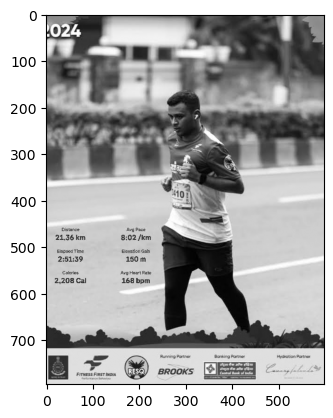

In [6]:
image=cv2.imread("D:/ippr/experiment_1/image.jpg")
#converting to grey scale 
image=cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
plt.imshow(image,cmap='gray')

Performing region splitting 

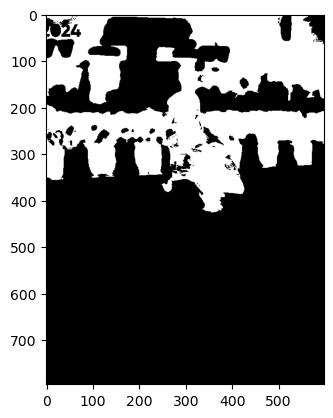

In [22]:
#defining seed point 
seed=(200,300)
#calculating height and width of the image 
h,w=image.shape
## initializing a list for visited and segmened nodes 
visited=np.zeros((h,w), dtype=np.uint8)
segmented=np.zeros((h,w),dtype=np.uint8)
# gets the intensity value at 200,300
seed_value=image[seed]
#initializes a queue and adds the seed pixel now we move outwards in a BFS style 
queue=deque([seed])
# mark seed as visited 
visited[seed]=1

# define the neighbours by 8 connectivity 
neighbours = [(-1,-1),(-1,0),(-1,1),
               (0,-1)       ,(0,1),
               (1,-1),(1,0),(1,1)]

threshold=80

while queue:
    x,y=queue.popleft() #<= pops the seed 
    segmented[x,y]=255 
    for dx,dy in neighbours: #<= from the 2D array of neighbours picks one 
        nx,ny=x+dx,y+dy #<= adds it to teh popped values i.e seed 
        if 0 <=nx <h and 0<=ny<w and not visited[nx,ny]: #<= checks if the neighbour is in the bound of the image
            if abs(int(image[nx,ny]) - int(seed_value)) <= threshold:
                #if the difference at pixel nx,ny is smaller than seed add the point to que
                queue.append((nx,ny)) #<== now pixel around this will be considered 
                # marking this as visited 
                visited[nx,ny]=1

#dislaying the segmented result 
plt.imshow(segmented,cmap='gray')

